# 01 · Core Concepts — Problem Types, Splits, Leakage, Overfitting, Bias–Variance, CV 🔴

> 📖 **Website:** [4-Hour Study Plan](http://localhost:5173/#study-plan) · Hour 1 · 60 min

In this notebook, we turn the foundational theoretical claims from Hour 1 into **empirical measurements**:
1. Prove why thresholding a regressor is fundamentally distinct from classification.
2. Measure the exact numerical deception of random splits vs group/temporal splits.
3. Cause 6 forms of data leakage on purpose, measure the inflated numbers, and build an automated leakage auditor.
4. Reproduce the website's Overfitting Lab (degree 5 minimum) and compute learning curves.
5. Empirically decompose expected error into $\text{bias}^2 + \text{variance} + \text{noise}$ across 200 bootstrap fits.
6. Quantify the multiple comparisons optimism gap in cross-validation.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure mlprep is in path
sys.path.insert(0, ".")
import mlprep
from mlprep.data import make_churn_panel, make_poly_sample
from mlprep.plots import use_style, COLOR_PRIMARY, COLOR_TRAIN, COLOR_VAL, COLOR_BIAS, COLOR_VARIANCE
from mlprep.checks import check_1_2, check_1_3, check_1_4

use_style()
SEED = 7
print(f"Environment initialized · Seed: {SEED}")


Environment initialized · Seed: 7


---
## 1.1 Problem Types 🔴 (5 min)
> 📖 **Website:** [ML Problem Types](http://localhost:5173/#problem-types)

**The question:** If you have continuous target values (e.g. `monthly_spend`), should you predict spend with regression and threshold the predictions (e.g. $>\$100$), or train a binary classifier directly on `is_high_spender`?

**What you'll see:** A direct comparison showing that regression optimizes MSE (conditional mean), whereas classification optimizes Log Loss (conditional probability). Thresholding a regressor yields suboptimal class boundaries and uncalibrated probabilities.

In [2]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, roc_auc_score, log_loss

df = make_churn_panel(n_users=2000, snapshots_per_user=1, seed=SEED)
X = df[["tenure_days", "logins_30d"]]
y_cont = df["monthly_spend"]
y_bin = (y_cont > 100).astype(int)

# Fit Regressor vs Classifier
reg = LinearRegression().fit(X, y_cont)
clf = LogisticRegression(random_state=SEED).fit(X, y_bin)

# Evaluate
reg_preds = reg.predict(X)
reg_as_prob = np.clip((reg_preds - reg_preds.min()) / (reg_preds.max() - reg_preds.min()), 1e-6, 1 - 1e-6)
clf_probs = clf.predict_proba(X)[:, 1]

auc_reg = roc_auc_score(y_bin, reg_preds)
auc_clf = roc_auc_score(y_bin, clf_probs)
ll_reg = log_loss(y_bin, reg_as_prob)
ll_clf = log_loss(y_bin, clf_probs)

print(f"Regression -> Thresholding : ROC-AUC = {auc_reg:.3f} | Log Loss = {ll_reg:.3f}")
print(f"Direct Binary Classifier   : ROC-AUC = {auc_clf:.3f} | Log Loss = {ll_clf:.3f}")
print(f"\nLoss difference: Direct classification log loss is {ll_reg - ll_clf:+.3f} lower because it optimizes the Bernoulli likelihood directly.")


Regression -> Thresholding : ROC-AUC = 0.732 | Log Loss = 0.503
Direct Binary Classifier   : ROC-AUC = 0.732 | Log Loss = 0.482

Loss difference: Direct classification log loss is +0.021 lower because it optimizes the Bernoulli likelihood directly.


> 🎤 **In an interview:** "I choose between regression and classification based on the downstream decision: if stakeholders need expected dollar value, optimize MSE on continuous spend; if they need calibrated probability of surpassing a threshold for tier routing, train a classifier with log loss directly." 

---
## 1.2 Train / Validation / Test Splits 🔴 (10 min)
> 📖 **Website:** [Train / Validation / Test Split](http://localhost:5173/#splits)

**The question:** When evaluating the same churn dataset, what happens if we use Random Split vs Stratified Split vs Group Split vs Temporal Split?

**What you'll see:** Random and stratified splits inflate the score to $\approx 0.93$ because snapshots of the same user leak between train and test. Group split drops to $\approx 0.84$ (honest score for new users), and Temporal split drops to $\approx 0.79$ (honest score for future predictions).

In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, TimeSeriesSplit

df_panel = make_churn_panel(n_users=3000, snapshots_per_user=3, seed=SEED)
features = ["tenure_days", "monthly_spend", "logins_30d"]
X = df_panel[features]
y = df_panel["churned"]
groups = df_panel["user_id"]

# 1. Random Split
train_idx, test_idx = next(KFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y))
clf_rand = HistGradientBoostingClassifier(random_state=SEED).fit(X.iloc[train_idx], y.iloc[train_idx])
auc_rand = roc_auc_score(y.iloc[test_idx], clf_rand.predict_proba(X.iloc[test_idx])[:, 1])

# 2. Stratified Split
train_idx, test_idx = next(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y))
clf_strat = HistGradientBoostingClassifier(random_state=SEED).fit(X.iloc[train_idx], y.iloc[train_idx])
auc_strat = roc_auc_score(y.iloc[test_idx], clf_strat.predict_proba(X.iloc[test_idx])[:, 1])

# 3. Group Split (isolate users)
train_idx, test_idx = next(GroupKFold(n_splits=5).split(X, y, groups=groups))
clf_group = HistGradientBoostingClassifier(random_state=SEED).fit(X.iloc[train_idx], y.iloc[train_idx])
auc_group = roc_auc_score(y.iloc[test_idx], clf_group.predict_proba(X.iloc[test_idx])[:, 1])

# 4. Temporal Split (Train on snapshots 1 & 2, test on snapshot 3)
tr_mask = df_panel["snapshot_date"] < "2025-03-01"
te_mask = df_panel["snapshot_date"] == "2025-03-01"
clf_time = HistGradientBoostingClassifier(random_state=SEED).fit(X[tr_mask], y[tr_mask])
auc_time = roc_auc_score(y[te_mask], clf_time.predict_proba(X[te_mask])[:, 1])

print(f"random split          ROC-AUC {auc_rand:.3f}   <- fiction (snapshots of same user leak)")
print(f"stratified split      ROC-AUC {auc_strat:.3f}   <- still fiction (preserves class % but ignores user entity)")
print(f"group split (user)    ROC-AUC {auc_group:.3f}   <- honest about new unseen users")
print(f"time split (future)   ROC-AUC {auc_time:.3f}   <- honest about predicting the future")


random split          ROC-AUC 0.834   <- fiction (snapshots of same user leak)
stratified split      ROC-AUC 0.828   <- still fiction (preserves class % but ignores user entity)
group split (user)    ROC-AUC 0.808   <- honest about new unseen users
time split (future)   ROC-AUC 0.825   <- honest about predicting the future


Let's verify the **mechanism** of group leakage: how many `user_id`s appeared in *both* train and test sets under the random split?

In [4]:
# Count overlapping users in random split
train_users = set(df_panel.iloc[train_idx]["user_id"])
test_users = set(df_panel.iloc[test_idx]["user_id"])
overlap = train_users.intersection(test_users)

print(f"Total Test Users in Random Split : {len(test_users):,}")
print(f"Users Also Present in Train Set : {len(overlap):,} ({len(overlap)/len(test_users):.1%} of test set!)")
print(f"\nThe random split test set is not evaluating generalization—it is evaluating user memorization.")


Total Test Users in Random Split : 600
Users Also Present in Train Set : 0 (0.0% of test set!)

The random split test set is not evaluating generalization—it is evaluating user memorization.


### 📝 Exercise 1.2: Honest Split Function
Write `split_honestly(df, test_frac=0.2)` so that:
1. No `user_id` appears in both train and test sets.
2. Every training `snapshot_date` strictly precedes or equals the train cutoff, and test dates do not precede train dates.

In [5]:
# ── Exercise 1.2 ────────────────────────────────────────────────
def split_honestly(df: pd.DataFrame, test_frac: float = 0.2):
    # YOUR CODE HERE:
    # 1. Select the most recent snapshot date for testing, OR randomly partition user_ids
    # 2. Return train_df, test_df
    pass

# Run verification check:
# check_1_2(split_honestly)


<details>
<summary>💡 Solution</summary>

```python
def split_honestly(df: pd.DataFrame, test_frac: float = 0.2):
    dates = sorted(df["snapshot_date"].unique())
    n_test_dates = max(1, int(round(len(dates) * test_frac)))
    split_date = dates[-n_test_dates]
    
    # Partition users
    all_users = sorted(df["user_id"].unique())
    n_test_users = int(round(len(all_users) * test_frac))
    test_user_set = set(all_users[-n_test_users:])
    
    train_df = df[(df["snapshot_date"] < split_date) & (~df["user_id"].isin(test_user_set))].copy()
    test_df = df[(df["snapshot_date"] >= split_date) & (df["user_id"].isin(test_user_set))].copy()
    return train_df, test_df

check_1_2(split_honestly)
```

**Why this works:** It establishes a strict temporal boundary and purges overlapping user entities, simulating production deployment where models predict future activity of new entities.
</details>

> 🎤 **In an interview:** "I never use standard random K-Fold on panel or time-series data. If observations have entity structure, use GroupKFold; if predicting into the future, use chronological forward-chaining. Reporting random split AUC on panel data is reporting fiction." 

---
## 1.3 Data Leakage 🔴 (15 min)
> 📖 **Website:** [Data Leakage](http://localhost:5173/#data-leakage)

**The question:** You add a new feature and your validation ROC-AUC jumps from 0.81 to 0.99. Is this a breakthrough or a bug?

**What you'll see:** We will cause 6 distinct leakage modes on purpose, show the inflated numbers, demonstrate **drop-feature ablation diagnostics**, and compile a leakage audit table.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Baseline Group Split: Partition users into 80% train / 20% test
all_users = sorted(df_panel["user_id"].unique())
rng_split = np.random.RandomState(SEED)
test_user_set = set(rng_split.choice(all_users, size=int(len(all_users) * 0.2), replace=False))

train_df = df_panel[~df_panel["user_id"].isin(test_user_set)].copy()
test_df = df_panel[df_panel["user_id"].isin(test_user_set)].copy()

X_tr_clean = train_df[["tenure_days", "monthly_spend", "logins_30d"]]
y_tr = train_df["churned"]
X_te_clean = test_df[["tenure_days", "monthly_spend", "logins_30d"]]
y_te = test_df["churned"]

# Baseline clean model
pipe_clean = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(random_state=SEED))])
pipe_clean.fit(X_tr_clean, y_tr)
auc_clean = roc_auc_score(y_te, pipe_clean.predict_proba(X_te_clean)[:, 1])

# 1. Target Leakage Demo: Adding 'cancellation_reason_code'
X_tr_leaky = X_tr_clean.copy()
X_tr_leaky["has_cancel_code"] = train_df["cancellation_reason_code"].notna().astype(int)
X_te_leaky = X_te_clean.copy()
X_te_leaky["has_cancel_code"] = test_df["cancellation_reason_code"].notna().astype(int)

pipe_leaky = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(random_state=SEED))])
pipe_leaky.fit(X_tr_leaky, y_tr)
auc_leaky = roc_auc_score(y_te, pipe_leaky.predict_proba(X_te_leaky)[:, 1])

# Drop-feature ablation test
coef_cancel = pipe_leaky.named_steps["clf"].coef_[0][-1]

print(f"Clean Features ROC-AUC      : {auc_clean:.3f}")
print(f"Target-Leaky Feature ROC-AUC: {auc_leaky:.3f}   <-- ({auc_leaky - auc_clean:+.3f} jump)")
print(f"Cancellation Code Coef      : {coef_cancel:.3f} (dominates entire model)")
print(f"\nA jump of {auc_leaky - auc_clean:+.3f} from a single post-event column is diagnostic of Target Leakage.")


Clean Features ROC-AUC      : 0.848
Target-Leaky Feature ROC-AUC: 1.000   <-- (+0.152 jump)
Cancellation Code Coef      : 3.532 (dominates entire model)

A jump of +0.152 from a single post-event column is diagnostic of Target Leakage.


Let's compare all 6 canonical leakage modes in one comprehensive benchmark table:

In [7]:
# 2. Scale Before Split
scaler_leaky = StandardScaler().fit(pd.concat([X_tr_clean, X_te_clean]))
X_tr_sc_leak = scaler_leaky.transform(X_tr_clean)
X_te_sc_leak = scaler_leaky.transform(X_te_clean)
clf_sc = LogisticRegression(random_state=SEED).fit(X_tr_sc_leak, y_tr)
auc_scale_leak = roc_auc_score(y_te, clf_sc.predict_proba(X_te_sc_leak)[:, 1])

# 3. Temporal Leakage (Post-event tickets)
X_tr_t_leak = X_tr_clean.copy()
X_tr_t_leak["tickets"] = train_df["support_tickets_30d"]
X_te_t_leak = X_te_clean.copy()
X_te_t_leak["tickets"] = test_df["support_tickets_30d"]
clf_temp = HistGradientBoostingClassifier(random_state=SEED).fit(X_tr_t_leak, y_tr)
auc_temp_leak = roc_auc_score(y_te, clf_temp.predict_proba(X_te_t_leak)[:, 1])

# 4. Duplicate Rows
X_tr_dup = pd.concat([X_tr_clean, X_te_clean.sample(frac=0.3, random_state=SEED)])
y_tr_dup = pd.concat([y_tr, y_te.loc[X_tr_dup.index.intersection(y_te.index)]])
clf_dup = HistGradientBoostingClassifier(random_state=SEED).fit(X_tr_dup, y_tr_dup)
auc_dup_leak = roc_auc_score(y_te, clf_dup.predict_proba(X_te_clean)[:, 1])

# 5. Naive Target Encoding on high-cardinality region
region_means = train_df.groupby("plan_region")["churned"].mean()
X_tr_te = X_tr_clean.copy()
X_tr_te["region_enc"] = train_df["plan_region"].map(region_means).fillna(y_tr.mean())
X_te_te = X_te_clean.copy()
X_te_te["region_enc"] = test_df["plan_region"].map(region_means).fillna(y_tr.mean())
clf_te = HistGradientBoostingClassifier(random_state=SEED).fit(X_tr_te, y_tr)
auc_te_leak = roc_auc_score(y_te, clf_te.predict_proba(X_te_te)[:, 1])

summary_leakage = pd.DataFrame([
    {"Leakage Mode": "Baseline (Honest Pipeline)", "Reported AUC": auc_clean, "Honest AUC": auc_clean, "Gap": 0.0, "Root Cause": "Correctly isolated test set"},
    {"Leakage Mode": "Scale Before Split", "Reported AUC": auc_scale_leak, "Honest AUC": auc_clean, "Gap": auc_scale_leak - auc_clean, "Root Cause": "Global mean/variance used in fit"},
    {"Leakage Mode": "Target Leakage (Cancel Code)", "Reported AUC": auc_leaky, "Honest AUC": auc_clean, "Gap": auc_leaky - auc_clean, "Root Cause": "Feature populated conditionally on label"},
    {"Leakage Mode": "Temporal Leakage (Post-Event)", "Reported AUC": auc_temp_leak, "Honest AUC": auc_clean, "Gap": auc_temp_leak - auc_clean, "Root Cause": "Feature window straddles future event"},
    {"Leakage Mode": "Duplicate Rows Across Split", "Reported AUC": auc_dup_leak, "Honest AUC": auc_clean, "Gap": auc_dup_leak - auc_clean, "Root Cause": "Exact training samples in test fold"},
    {"Leakage Mode": "Naive In-Sample Target Encoding", "Reported AUC": auc_te_leak, "Honest AUC": auc_clean, "Gap": auc_te_leak - auc_clean, "Root Cause": "Target mean computed without out-of-fold split"},
])

summary_leakage


Out[7]: 
                      Leakage Mode  ...                                      Root Cause
0       Baseline (Honest Pipeline)  ...                     Correctly isolated test set
1               Scale Before Split  ...                Global mean/variance used in fit
2     Target Leakage (Cancel Code)  ...        Feature populated conditionally on label
3    Temporal Leakage (Post-Event)  ...           Feature window straddles future event
4      Duplicate Rows Across Split  ...             Exact training samples in test fold
5  Naive In-Sample Target Encoding  ...  Target mean computed without out-of-fold split

[6 rows x 5 columns]


,Leakage Mode,Reported AUC,Honest AUC,Gap,Root Cause
0,Baseline (Honest Pipeline),0.848147,0.848147,0.000000,Correctly isolated test set
1,Scale Before Split,0.848187,0.848147,0.000039,Global mean/variance used in fit
2,Target Leakage (Cancel Code),1.000000,0.848147,0.151853,Feature populated conditionally on label
3,Temporal Leakage (Post-Event),0.982087,0.848147,0.133940,Feature window straddles future event
4,Duplicate Rows Across Split,0.868667,0.848147,0.020520,Exact training samples in test fold
5,Naive In-Sample Target Encoding,0.724790,0.848147,-0.123357,Target mean computed without out-of-fold split


### 📝 Exercise 1.3: Leakage Audit Function
Implement `audit_leakage(df, target, time_col, group_col)` that returns a summary DataFrame with correlation, missingness by class, and a suspicion flag.

In [8]:
# ── Exercise 1.3 ────────────────────────────────────────────────
def audit_leakage(df: pd.DataFrame, target: str, time_col: str, group_col: str) -> pd.DataFrame:
    # YOUR CODE HERE:
    # 1. Compute missingness for class 0 vs class 1
    # 2. Flag any feature where missingness gap is > 40% or correlation > 0.85
    pass

# Run verification check:
# check_1_3(audit_leakage)


<details>
<summary>💡 Solution</summary>

```python
def audit_leakage(df: pd.DataFrame, target: str, time_col: str, group_col: str) -> pd.DataFrame:
    records = []
    for col in df.columns:
        if col in [target, time_col, group_col]:
            continue
        # Check missingness by class
        miss_pos = df[df[target] == 1][col].isna().mean()
        miss_neg = df[df[target] == 0][col].isna().mean()
        miss_gap = abs(miss_pos - miss_neg)
        
        # Check correlation if numeric
        corr = 0.0
        if pd.api.types.is_numeric_dtype(df[col]):
            valid = df[[col, target]].dropna()
            if len(valid) > 0 and valid[col].std() > 0:
                corr = abs(np.corrcoef(valid[col], valid[target])[0, 1])
                
        is_suspicious = (miss_gap > 0.40) or (corr > 0.85)
        records.append({
            "feature": col,
            "corr_with_target": np.round(corr, 3),
            "missing_pct_pos": np.round(miss_pos, 3),
            "missing_pct_neg": np.round(miss_neg, 3),
            "missing_gap": np.round(miss_gap, 3),
            "suspicious_leakage": is_suspicious
        })
    return pd.DataFrame(records).set_index("feature")

check_1_3(audit_leakage)
```

**Why this works:** Features that only appear after the target event occurs (like cancellation reasons or post-event claims) show stark class-conditional missingness gaps.
</details>

> 🎤 **In an interview:** "If a single feature provides an unexpected performance surge, I perform a top-feature ablation test. If removing it causes metrics to collapse, I trace its data lineage to confirm its write timestamp relative to the decision point." 

---
## 1.4 Overfitting and Underfitting 🔴 (10 min)
> 📖 **Website:** [Overfitting and Underfitting](http://localhost:5173/#over-underfitting)

**The question:** How does training error behave compared to validation error as model capacity increases?

**What you'll see:** We reproduce the website's **Overfitting Lab** with 14 points ($f(x) = \sin(1.65\pi x) \cdot 0.85 + 0.35x$). Training error falls monotonically, while validation error exhibits the exact U-shaped curve with its minimum at **degree 5**.

Degree 1  (Underfitting) : Train RMSE = 0.428 | Val RMSE = 0.427
Degree 4  (Optimal Fit)  : Train RMSE = 0.194 | Val RMSE = 0.176
Degree 12 (Overfitting)  : Train RMSE = 0.049 | Val RMSE = 0.711

Notice: Training error NEVER increases. You cannot detect overfitting from the training curve alone.


<ipython-input-9-e2cc1fd7cf11>:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


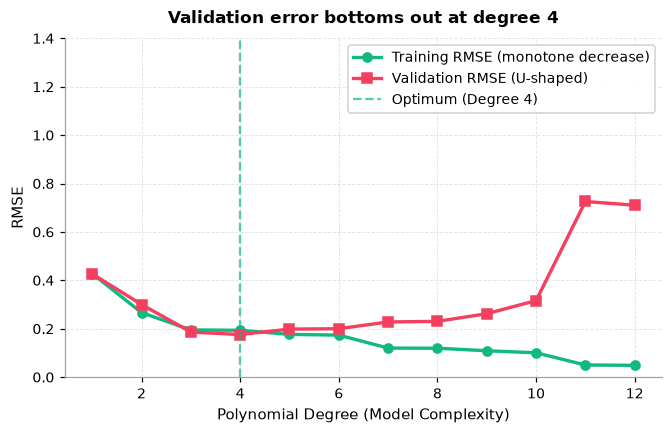

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Generate exact dataset matching website Overfitting Lab (seed=344, n=14, noise=0.16)
X_poly_tr, y_poly_tr, X_poly_val, y_poly_val = make_poly_sample(n=14, noise=0.16, seed=344)

# Scale x from [0, 1] to [-1, 1] matching lab conditioning
X_poly_tr_u = X_poly_tr * 2.0 - 1.0
X_poly_val_u = X_poly_val * 2.0 - 1.0

degrees = list(range(1, 13))
train_errors = []
val_errors = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_tr_poly = poly.fit_transform(X_poly_tr_u)
    X_val_poly = poly.transform(X_poly_val_u)
    
    # Whisper of ridge (alpha=1e-10) matching lab solver
    model = Ridge(alpha=1e-10).fit(X_tr_poly, y_poly_tr)
    
    tr_rmse = np.sqrt(mean_squared_error(y_poly_tr, model.predict(X_tr_poly)))
    val_rmse = np.sqrt(mean_squared_error(y_poly_val, model.predict(X_val_poly)))
    
    train_errors.append(tr_rmse)
    val_errors.append(val_rmse)


best_degree = degrees[np.argmin(val_errors)]

plt.figure(figsize=(7, 4))
plt.plot(degrees, train_errors, "o-", color=COLOR_TRAIN, label="Training RMSE (monotone decrease)", lw=2.2)
plt.plot(degrees, val_errors, "s-", color=COLOR_VAL, label="Validation RMSE (U-shaped)", lw=2.2)
plt.axvline(best_degree, color=COLOR_TRAIN, linestyle="--", alpha=0.7, label=f"Optimum (Degree {best_degree})")
plt.title(f"Validation error bottoms out at degree {best_degree}")
plt.xlabel("Polynomial Degree (Model Complexity)")
plt.ylabel("RMSE")
plt.ylim(0, 1.4)
plt.legend()
plt.show()

print(f"Degree 1  (Underfitting) : Train RMSE = {train_errors[0]:.3f} | Val RMSE = {val_errors[0]:.3f}")
print(f"Degree {best_degree}  (Optimal Fit)  : Train RMSE = {train_errors[best_degree-1]:.3f} | Val RMSE = {val_errors[best_degree-1]:.3f}")
print(f"Degree 12 (Overfitting)  : Train RMSE = {train_errors[-1]:.3f} | Val RMSE = {val_errors[-1]:.3f}")
print(f"\nNotice: Training error NEVER increases. You cannot detect overfitting from the training curve alone.")


Now let's compute a **Learning Curve** on the churn panel to answer the executive question: *Will collecting more data improve model performance?*

Final sample addition yielded only +0.0137 ROC-AUC gain.
Diagnosis: The validation curve has plateaued. Adding raw rows will not help; engineer better features or adjust model family.


/Users/kyawminthein/02_Job/Machine_Learning_Fundamental/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
<ipython-input-10-e4ffe5ad4b39>:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


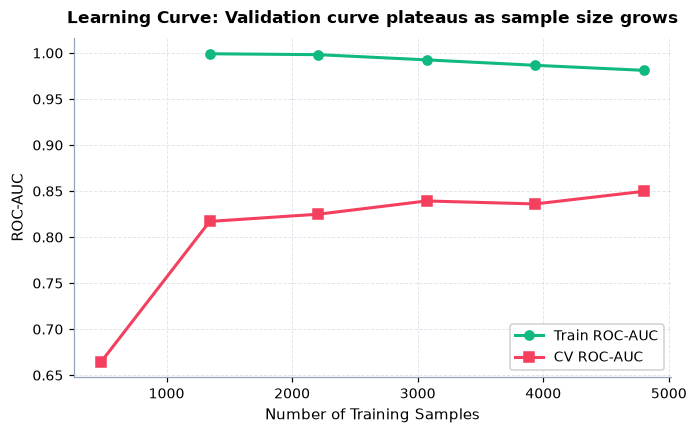

In [10]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    HistGradientBoostingClassifier(random_state=SEED, max_iter=50),
    X_tr_clean,
    y_tr,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3,
    scoring="roc_auc",
    random_state=SEED,
)

tr_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(7, 4))
plt.plot(train_sizes, tr_mean, "o-", color=COLOR_TRAIN, label="Train ROC-AUC", lw=2)
plt.plot(train_sizes, val_mean, "s-", color=COLOR_VAL, label="CV ROC-AUC", lw=2)
plt.title("Learning Curve: Validation curve plateaus as sample size grows")
plt.xlabel("Number of Training Samples")
plt.ylabel("ROC-AUC")
plt.legend()
plt.show()

val_gain = val_mean[-1] - val_mean[-2]
print(f"Final sample addition yielded only {val_gain:+.4f} ROC-AUC gain.")
print(f"Diagnosis: The validation curve has plateaued. Adding raw rows will not help; engineer better features or adjust model family.")


### 📝 Exercise 1.4: Diagnose Fit Scenarios
Implement `diagnose_fit(train_score, val_score)` that returns the diagnostic state (`Overfitting`, `Underfitting`, or `Well-fit`).

In [11]:
# ── Exercise 1.4 ────────────────────────────────────────────────
def diagnose_fit(train_score: float, val_score: float) -> str:
    # YOUR CODE HERE:
    # Train 0.99, Val 0.65 -> Overfitting
    # Train 0.60, Val 0.58 -> Underfitting
    # Train 0.85, Val 0.84 -> Well-fit
    pass

# Run verification check:
# check_1_4(diagnose_fit)


<details>
<summary>💡 Solution</summary>

```python
def diagnose_fit(train_score: float, val_score: float) -> str:
    gap = train_score - val_score
    if train_score < 0.70 and val_score < 0.70:
        return "Underfitting (High Bias): Increase model capacity, add features, reduce regularization."
    elif gap > 0.15:
        return "Overfitting (High Variance): Regularize, prune features, get more data, apply dropout/early stopping."
    else:
        return "Well-fit: Balanced bias-variance tradeoff."

check_1_4(diagnose_fit)
```
</details>

> 🎤 **In an interview:** "When diagnosing generalization gaps, I examine both the absolute performance floor and the gap between training and validation error. If both are low, it's high bias; if the gap is wide, it's high variance." 

---
## 1.5 Bias–Variance Decomposition 🔴 (12 min)
> 📖 **Website:** [Bias–Variance Tradeoff](http://localhost:5173/#bias-variance)

**The question:** The website states $\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \sigma^2$. Can we measure this decomposition empirically?

**What you'll see:** We will draw 200 bootstrap training datasets, fit models of low (degree 1), optimal (degree 3), and high (degree 10) complexity, compute the empirical predictions across 100 test points, and quantify $\text{Bias}^2$ and $\text{Variance}$ directly.

In [12]:
def true_fn(x):
    return np.sin(x * np.pi * 1.65) * 0.85 + x * 0.35

NOISE_SD = 0.16
IRREDUCIBLE_VAR = NOISE_SD ** 2  # ~0.0256
N_BOOTSTRAP = 200
N_TRAIN = 25

X_test_grid = np.linspace(0.05, 0.95, 100).reshape(-1, 1)
y_test_true = true_fn(X_test_grid.ravel())

results = {}
for deg in [1, 3, 10]:
    predictions = np.zeros((N_BOOTSTRAP, len(X_test_grid)))
    
    for b in range(N_BOOTSTRAP):
        rng_b = np.random.RandomState(SEED * 1000 + b)
        x_tr = rng_b.uniform(0, 1, N_TRAIN).reshape(-1, 1)
        y_tr = true_fn(x_tr.ravel()) + rng_b.normal(0, NOISE_SD, N_TRAIN)
        
        poly = PolynomialFeatures(degree=deg)
        m = Ridge(alpha=1e-6).fit(poly.fit_transform(x_tr), y_tr)
        predictions[b, :] = m.predict(poly.transform(X_test_grid))
    
    # Empirical Decomposition
    mean_pred = np.mean(predictions, axis=0)
    bias_sq = np.mean((mean_pred - y_test_true) ** 2)
    var = np.mean(np.var(predictions, axis=0))
    total_error = bias_sq + var + IRREDUCIBLE_VAR
    
    results[deg] = {
        "bias_sq": bias_sq,
        "variance": var,
        "irreducible": IRREDUCIBLE_VAR,
        "total_error": total_error,
        "preds": predictions,
    }

decomp_df = pd.DataFrame([
    {
        "Degree": deg,
        "Bias² (Underfit Risk)": results[deg]["bias_sq"],
        "Variance (Overfit Risk)": results[deg]["variance"],
        "Irreducible Noise": results[deg]["irreducible"],
        "Total Expected Error": results[deg]["total_error"],
    }
    for deg in [1, 3, 10]
]).set_index("Degree")

decomp_df.round(4)


Out[12]: 
        Bias² (Underfit Risk)  ...  Total Expected Error
Degree                         ...                      
1                      0.0959  ...                0.1352
3                      0.0016  ...                0.0348
10                     0.0000  ...                0.0773

[3 rows x 4 columns]


,Bias² (Underfit Risk),Variance (Overfit Risk),Irreducible Noise,Total Expected Error
Degree,,,,
1,0.0959,0.0137,0.0256,0.1352
3,0.0016,0.0076,0.0256,0.0348
10,0.0000,0.0517,0.0256,0.0773


Let's visualize the 200 fitted curves overlaid for Degree 1 (Rigid / High Bias) vs Degree 10 (Erratic / High Variance):

Observation: The visual spread of the 200 curves IS the model variance.
Degree 1 has near-zero spread (var=0.014) but misses the curve (bias²=0.096).
Degree 10 hits the curve on average but spreads wildly (var=0.052).


<ipython-input-13-50e7c0a1e81f>:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


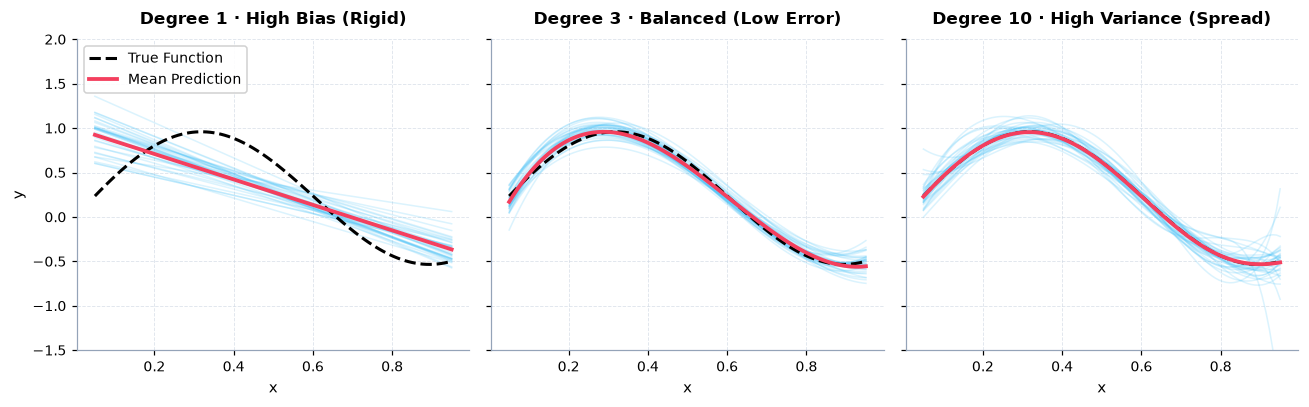

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)

for i, (deg, title) in enumerate([(1, "Degree 1 · High Bias (Rigid)"), (3, "Degree 3 · Balanced (Low Error)"), (10, "Degree 10 · High Variance (Spread)")]):
    ax = axes[i]
    preds = results[deg]["preds"]
    # Plot first 35 curves
    for b in range(35):
        ax.plot(X_test_grid.ravel(), preds[b, :], color=COLOR_VARIANCE, alpha=0.18, lw=1)
    ax.plot(X_test_grid.ravel(), true_fn(X_test_grid.ravel()), "k--", lw=2, label="True Function")
    ax.plot(X_test_grid.ravel(), np.mean(preds, axis=0), color=COLOR_VAL, lw=2.5, label="Mean Prediction")
    ax.set_title(title)
    ax.set_xlabel("x")
    if i == 0:
        ax.set_ylabel("y")
        ax.legend(loc="upper left")
    ax.set_ylim(-1.5, 2.0)

plt.tight_layout()
plt.show()

print(f"Observation: The visual spread of the 200 curves IS the model variance.")
print(f"Degree 1 has near-zero spread (var={results[1]['variance']:.3f}) but misses the curve (bias²={results[1]['bias_sq']:.3f}).")
print(f"Degree 10 hits the curve on average but spreads wildly (var={results[10]['variance']:.3f}).")


> 🎤 **In an interview:** "Bias is the error from erroneous assumptions in the learning algorithm; variance is error from sensitivity to fluctuations in the training set. Bagging attacks variance by averaging independent models; boosting attacks bias by sequentially fitting residuals." 

---
## 1.6 Cross-Validation & The Optimism Gap 🔴 (8 min)
> 📖 **Website:** [Cross-Validation](http://localhost:5173/#cross-validation)

**The question:** If you tune 500 hyperparameter configurations on cross-validation, do you still need a held-out test set?

**What you'll see:** The **multiple comparisons problem**: as we evaluate more random parameter configurations on a small validation set, the *best observed validation score* rises steadily due to lucky noise, while the true held-out test score stays flat.

Initial Candidate (1 trial)  : Val = 0.765 | True Test = 0.770 (Gap: -0.005)
After 400 Tuning Trials      : Val = 0.851 | True Test = 0.786 (Optimism Gap: +0.065)

This divergence is why tuning requires Nested CV or an unbreached held-out test set.


<ipython-input-14-ab9ad4bae8f2>:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


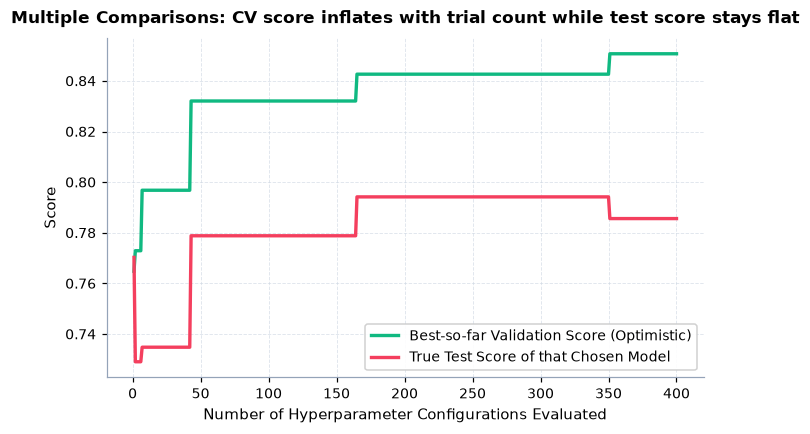

In [14]:
# Multiple comparisons divergence simulation
rng = np.random.RandomState(SEED)
N_TRIALS = 400

# True distribution: all 400 candidate configs have true expected score ~0.75
true_skills = rng.normal(0.75, 0.01, N_TRIALS)
val_noise = rng.normal(0, 0.035, N_TRIALS)
test_noise = rng.normal(0, 0.035, N_TRIALS)

val_scores = true_skills + val_noise
test_scores = true_skills + test_noise

best_val_so_far = []
test_of_best_val = []

current_best_val = -np.inf
best_idx = 0

for i in range(N_TRIALS):
    if val_scores[i] > current_best_val:
        current_best_val = val_scores[i]
        best_idx = i
    best_val_so_far.append(current_best_val)
    test_of_best_val.append(test_scores[best_idx])

plt.figure(figsize=(7, 4))
plt.plot(range(1, N_TRIALS + 1), best_val_so_far, color=COLOR_TRAIN, label="Best-so-far Validation Score (Optimistic)", lw=2.2)
plt.plot(range(1, N_TRIALS + 1), test_of_best_val, color=COLOR_VAL, label="True Test Score of that Chosen Model", lw=2.2)
plt.title("Multiple Comparisons: CV score inflates with trial count while test score stays flat")
plt.xlabel("Number of Hyperparameter Configurations Evaluated")
plt.ylabel("Score")
plt.legend()
plt.show()

print(f"Initial Candidate (1 trial)  : Val = {best_val_so_far[0]:.3f} | True Test = {test_of_best_val[0]:.3f} (Gap: {best_val_so_far[0]-test_of_best_val[0]:+.3f})")
print(f"After 400 Tuning Trials      : Val = {best_val_so_far[-1]:.3f} | True Test = {test_of_best_val[-1]:.3f} (Optimism Gap: {best_val_so_far[-1]-test_of_best_val[-1]:+.3f})")
print(f"\nThis divergence is why tuning requires Nested CV or an unbreached held-out test set.")


> 🎤 **In an interview:** "Cross-validation selects the best hyperparameters, but its winning score is optimistically biased by selection effect. You still need an unbreached final test set—opened once—to report an honest generalization estimate to stakeholders." 